In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing.constants as C

In [2]:
sns.set_context("notebook")
sns.set_style("whitegrid")
sns.set_theme(

    rc={"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

        "axes.labelsize": 13,
        "axes.titlesize": 15,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,

        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.0})

Now, the name of the file doesn't start with "ELM19", because the dataset has already been preprocessed and it not equal to original sourced from Poziomska et. al.

In [3]:
head = f'{C.BASE_DIR}/magisterka/metadata/'
dataset = "ELM19"
filename_1 = f'{head}/metadata_exams.csv'
filename_2 = f'{head}/metadata_sites.csv'
filename_3 = f'{head}/metadata_longitudinal.csv'
FIGURE_DIR = f'{head}/figures/{dataset}'

## exams

In [4]:
data = pd.read_csv(filename_1)

In [5]:
data.head()

,site,sub_id,exam_id,age,age_group,female,pathology
0,S17,sub-000,20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f...,56.6,56-65,0,0
1,S12,sub-001,20220510-150544-{cc1f09f8-3b30-40b4-91f8-4cd70...,38.0,36-45,0,1
2,S01,sub-002,20220412-172841-{0881d6c7-8c23-4389-87c1-58c8e...,20.4,16-25,0,1
3,S23,sub-003,20220530-182538-{85ec4ff0-fd03-4be2-a44b-99723...,23.6,16-25,1,1
4,S00,sub-004,20220512-152511-{61074308-a109-40b1-97cb-43dcb...,60.6,56-65,0,1


In [6]:
#!pip install dython

https://shakedzy.xyz/dython/modules/nominal/

To investigate the correlation between metadata features a smart wrapper function of various correlation calculation methods (associations from dython.nominal) must be implemented.

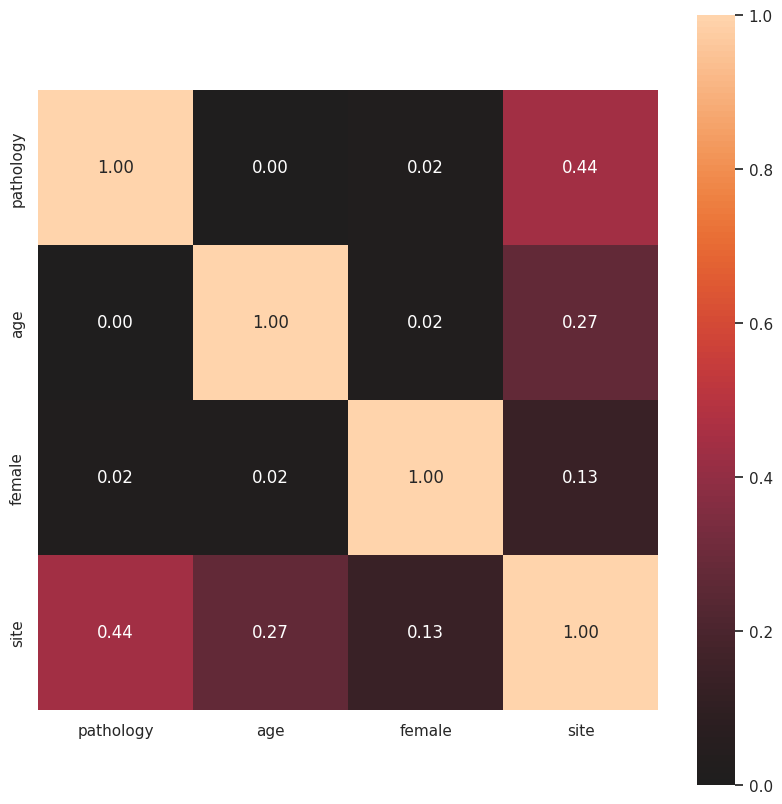

{'corr':            pathology       age    female      site
 pathology   1.000000  0.000873  0.020162  0.438164
 age         0.000873  1.000000  0.021045  0.272309
 female      0.020162  0.021045  1.000000  0.133176
 site        0.438164  0.272309  0.133176  1.000000,
 'ax': <Axes: >}

In [7]:
from dython.nominal import associations
cols = ["pathology", "age", "female", "site"]

associations(
    data[cols],
    nominal_columns=["pathology", "female", "site"],
    numerical_columns=["age"],
    figsize = (10,10)
)

The most concerning correlation, is a very high one between site & pathology.

In [8]:
LABEL_PALETTE = {'0': "#4A90E2", '1': "#E06666"}
SEX_PALETTE = {'0': "#00A878", '1': "#9B51E0"}

bins = [0, 1]
label_labels = ['Norm', 'Pathology']
sex_labels = ['Male', 'Female']

In [9]:
order = ['16-25', '26-35', '36-45','46-55', '56-65']

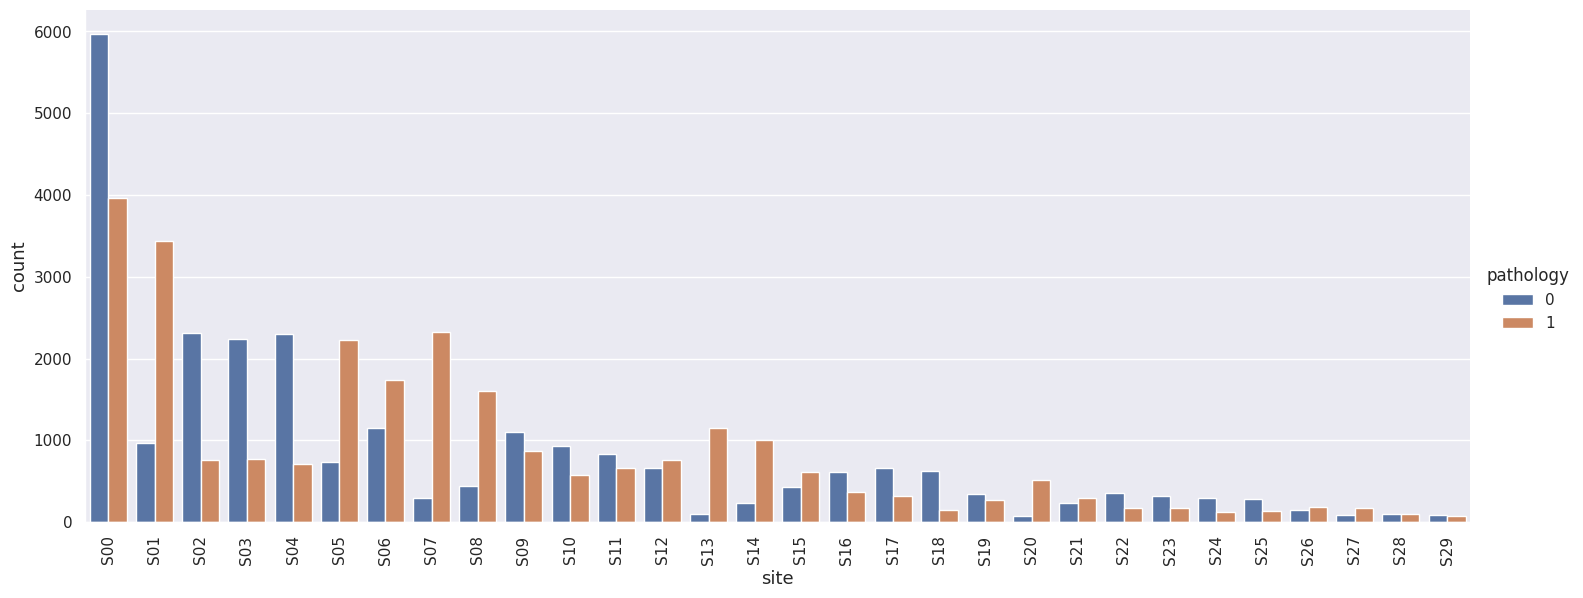

In [10]:
g = sns.catplot(x='site',
                hue='pathology',
                data=data,
                kind='count',
                order=data['site'].value_counts().index,
                height=6,
                aspect=2.5)

g.set_xticklabels(rotation=90)

Even though the whole dataset is well-balanced in terms of control and pathological clinical groups, the inter-site distribution is very unequal, so different sites should definitely not be treated as seperate datasets (before balancing with respective weights and/or subsampling from the majority group).

This is a huge problem with heterogenous datasets and demand harmonization, not to overshadow any underlying neural patterns. Let's try to build naive-nauroscreener, the logistic regressor only on the metadata. This is a dignostic step to later compare with deep learning x functional connectivity (eeg) approach.

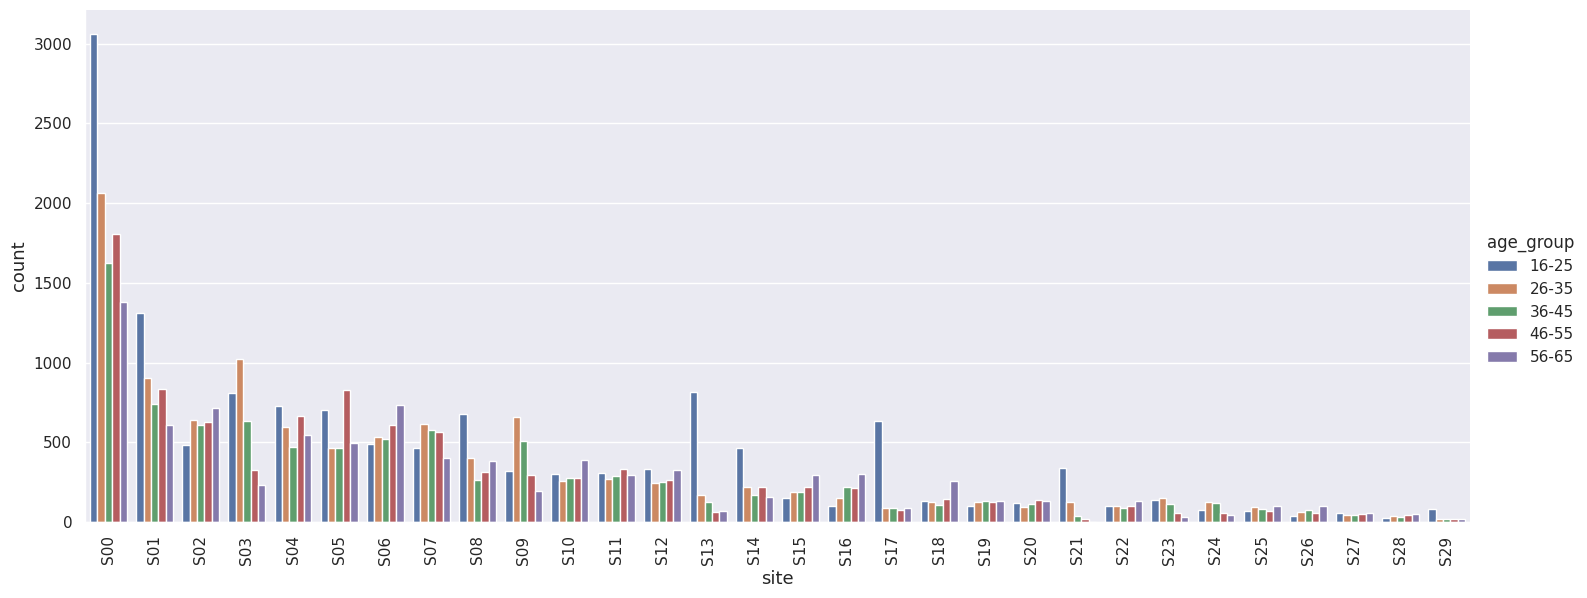

In [11]:
g = sns.catplot(x='site',
                hue='age_group',
                hue_order= order,
                data=data,
                kind='count',
                order=data['site'].value_counts().index,
                height=6,
                aspect=2.5)

g.set_xticklabels(rotation=90)

Some sites can be also easily disingushed by majority age group (young: S00, S13, S17). Age is a tricky confunder, because it is assumed to be correlated with health condition.

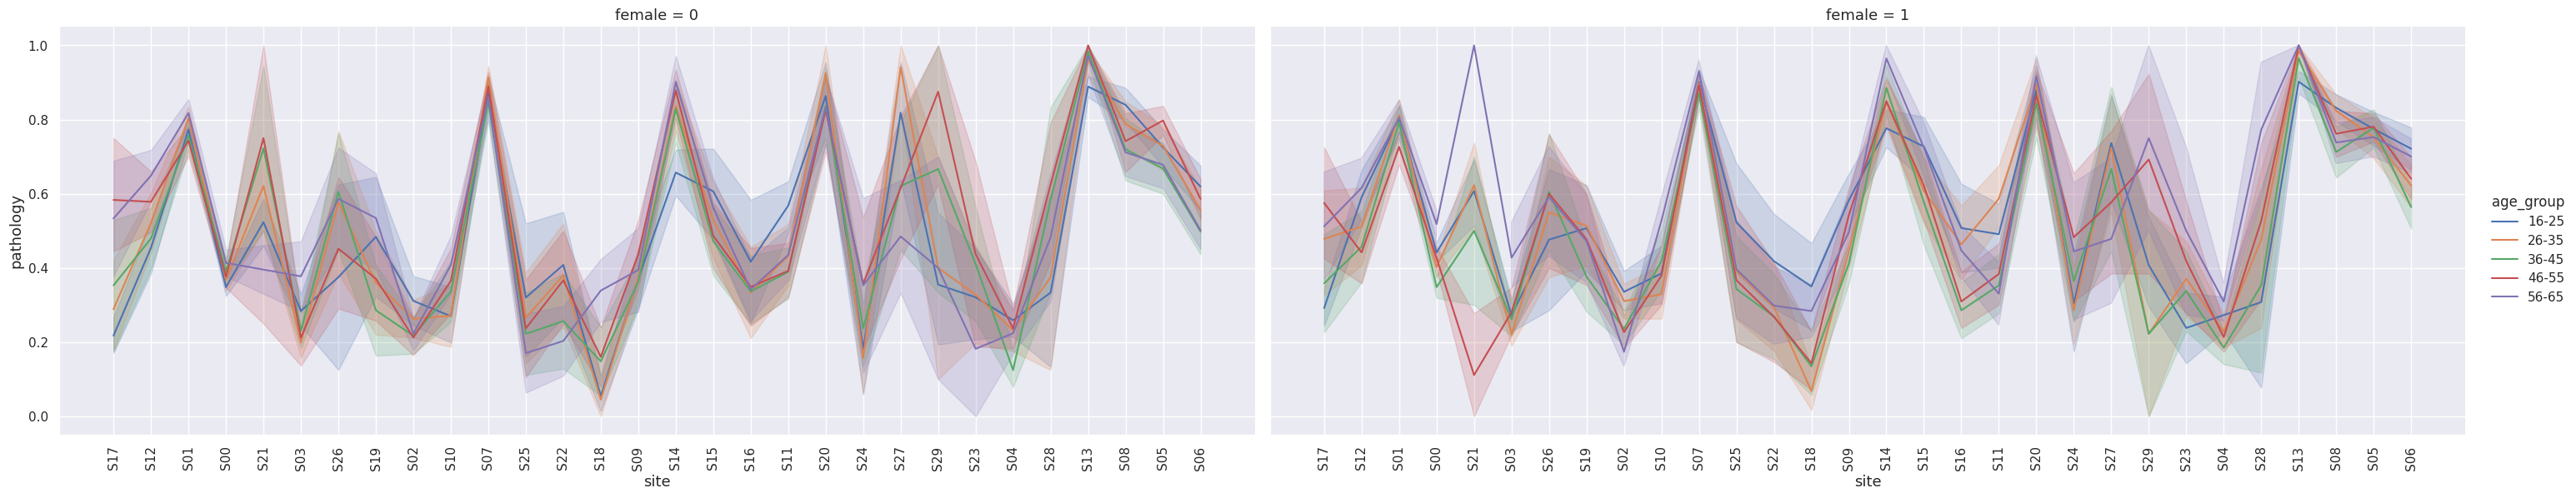

In [12]:
g = sns.relplot(x='site',
                y = "pathology",
                hue='age_group',
                hue_order= order,
                data=data,
                col = "female",
                kind='line',
                height=6,
                aspect=2.5)

g.set_xticklabels(rotation=90)

Potentially, S21 is a candidate for removal. Huge correlation between age and label.

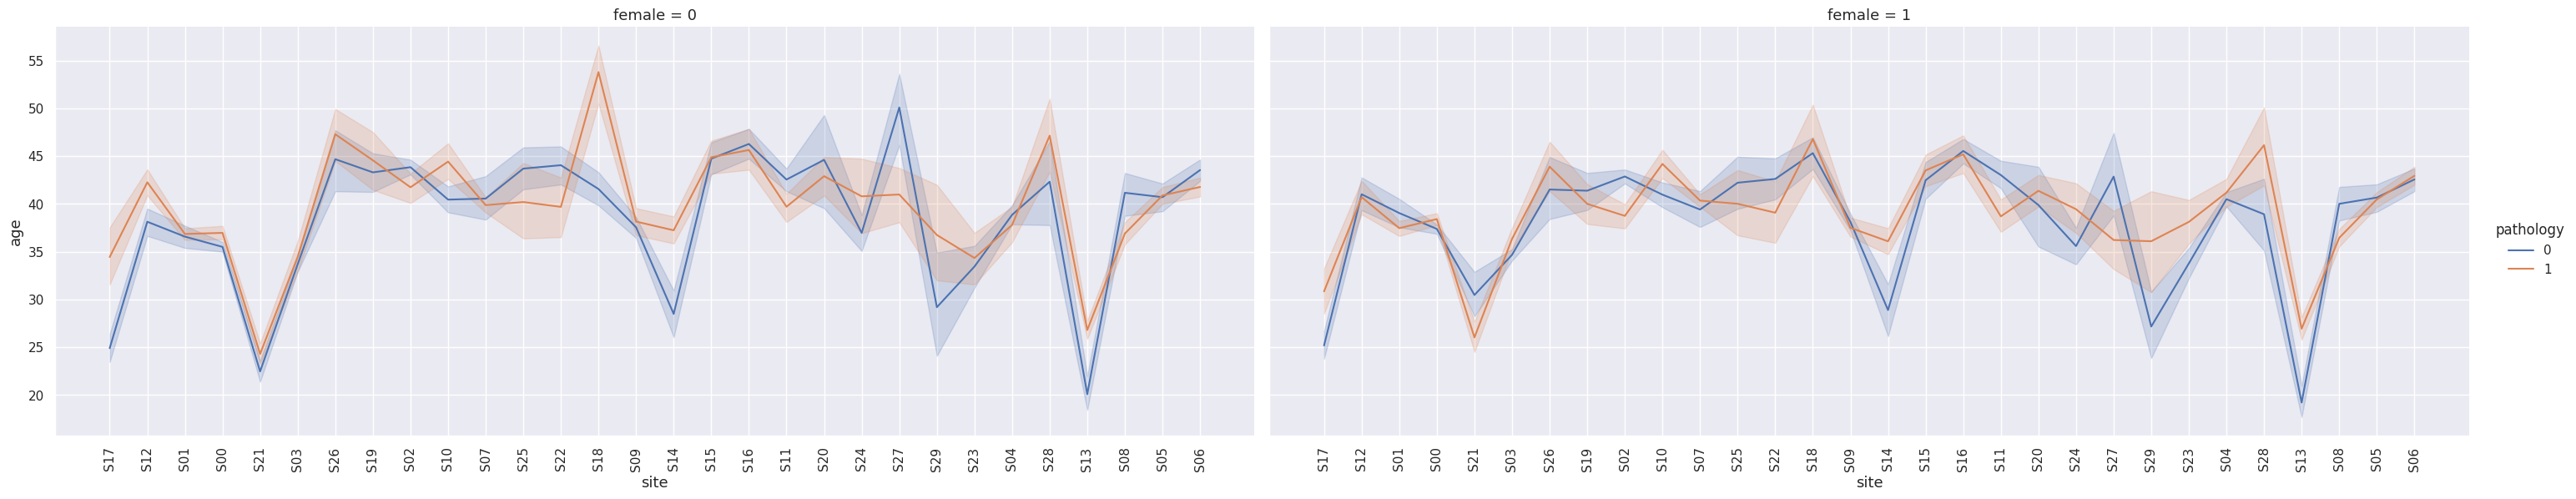

In [13]:
g = sns.relplot(x='site',
                y = "age",
                hue='pathology',
                data=data,
                kind='line',
                col = "female",
                height=6,
                aspect=2.5,
                sort = True)

g.set_xticklabels(rotation=90)

## sites

In [14]:
data = pd.read_csv(filename_2)
data_long = pd.read_csv(filename_3)

In [15]:
data.head()

,site,#exams,#unique_subs,#unique_long_subs,long_subs_and#
0,S00,9930,8184,948,"{'sub-004': 9930, 'sub-005': 9930, 'sub-006': ..."
1,S01,4401,3700,504,"{'sub-002': 4401, 'sub-014': 4401, 'sub-030': ..."
2,S02,3073,2470,354,"{'sub-024': 3073, 'sub-029': 3073, 'sub-031': ..."
3,S03,3017,1570,177,"{'sub-008': 3017, 'sub-016': 3017, 'sub-019': ..."
4,S04,3003,2062,410,"{'sub-3204': 3003, 'sub-3205': 3003, 'sub-3206..."


In [16]:
data_long.head()

,site,sub_id,n_exams
0,S00,sub-004,2
1,S00,sub-005,2
2,S00,sub-006,2
3,S00,sub-009,17
4,S00,sub-013,2


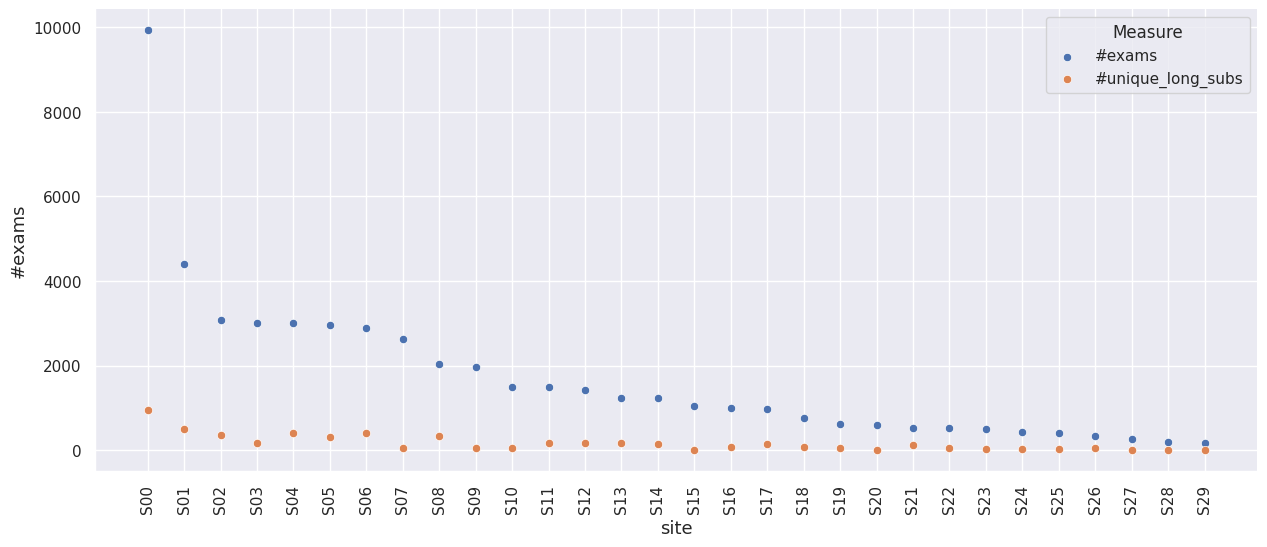

In [17]:
fig, ax = plt.subplots(figsize=(15, 6))

order = data['site'].value_counts().index

sns.scatterplot(
    data=data, x='site', y='#exams',
    ax=ax, label='#exams'
)

sns.scatterplot(
    data=data, x='site', y='#unique_long_subs',
    ax=ax, label='#unique_long_subs'
)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=90)
ax.legend(title='Measure')

In [18]:
data_long

,site,sub_id,n_exams
0,S00,sub-004,2
1,S00,sub-005,2
2,S00,sub-006,2
3,S00,sub-009,17
4,S00,sub-013,2
...,...,...,...
4863,S29,sub-22790,2
4864,S29,sub-29277,2
4865,S29,sub-29283,2
4866,S29,sub-29284,2


AttributeError: Line2D.set() got an unexpected keyword argument 'size'

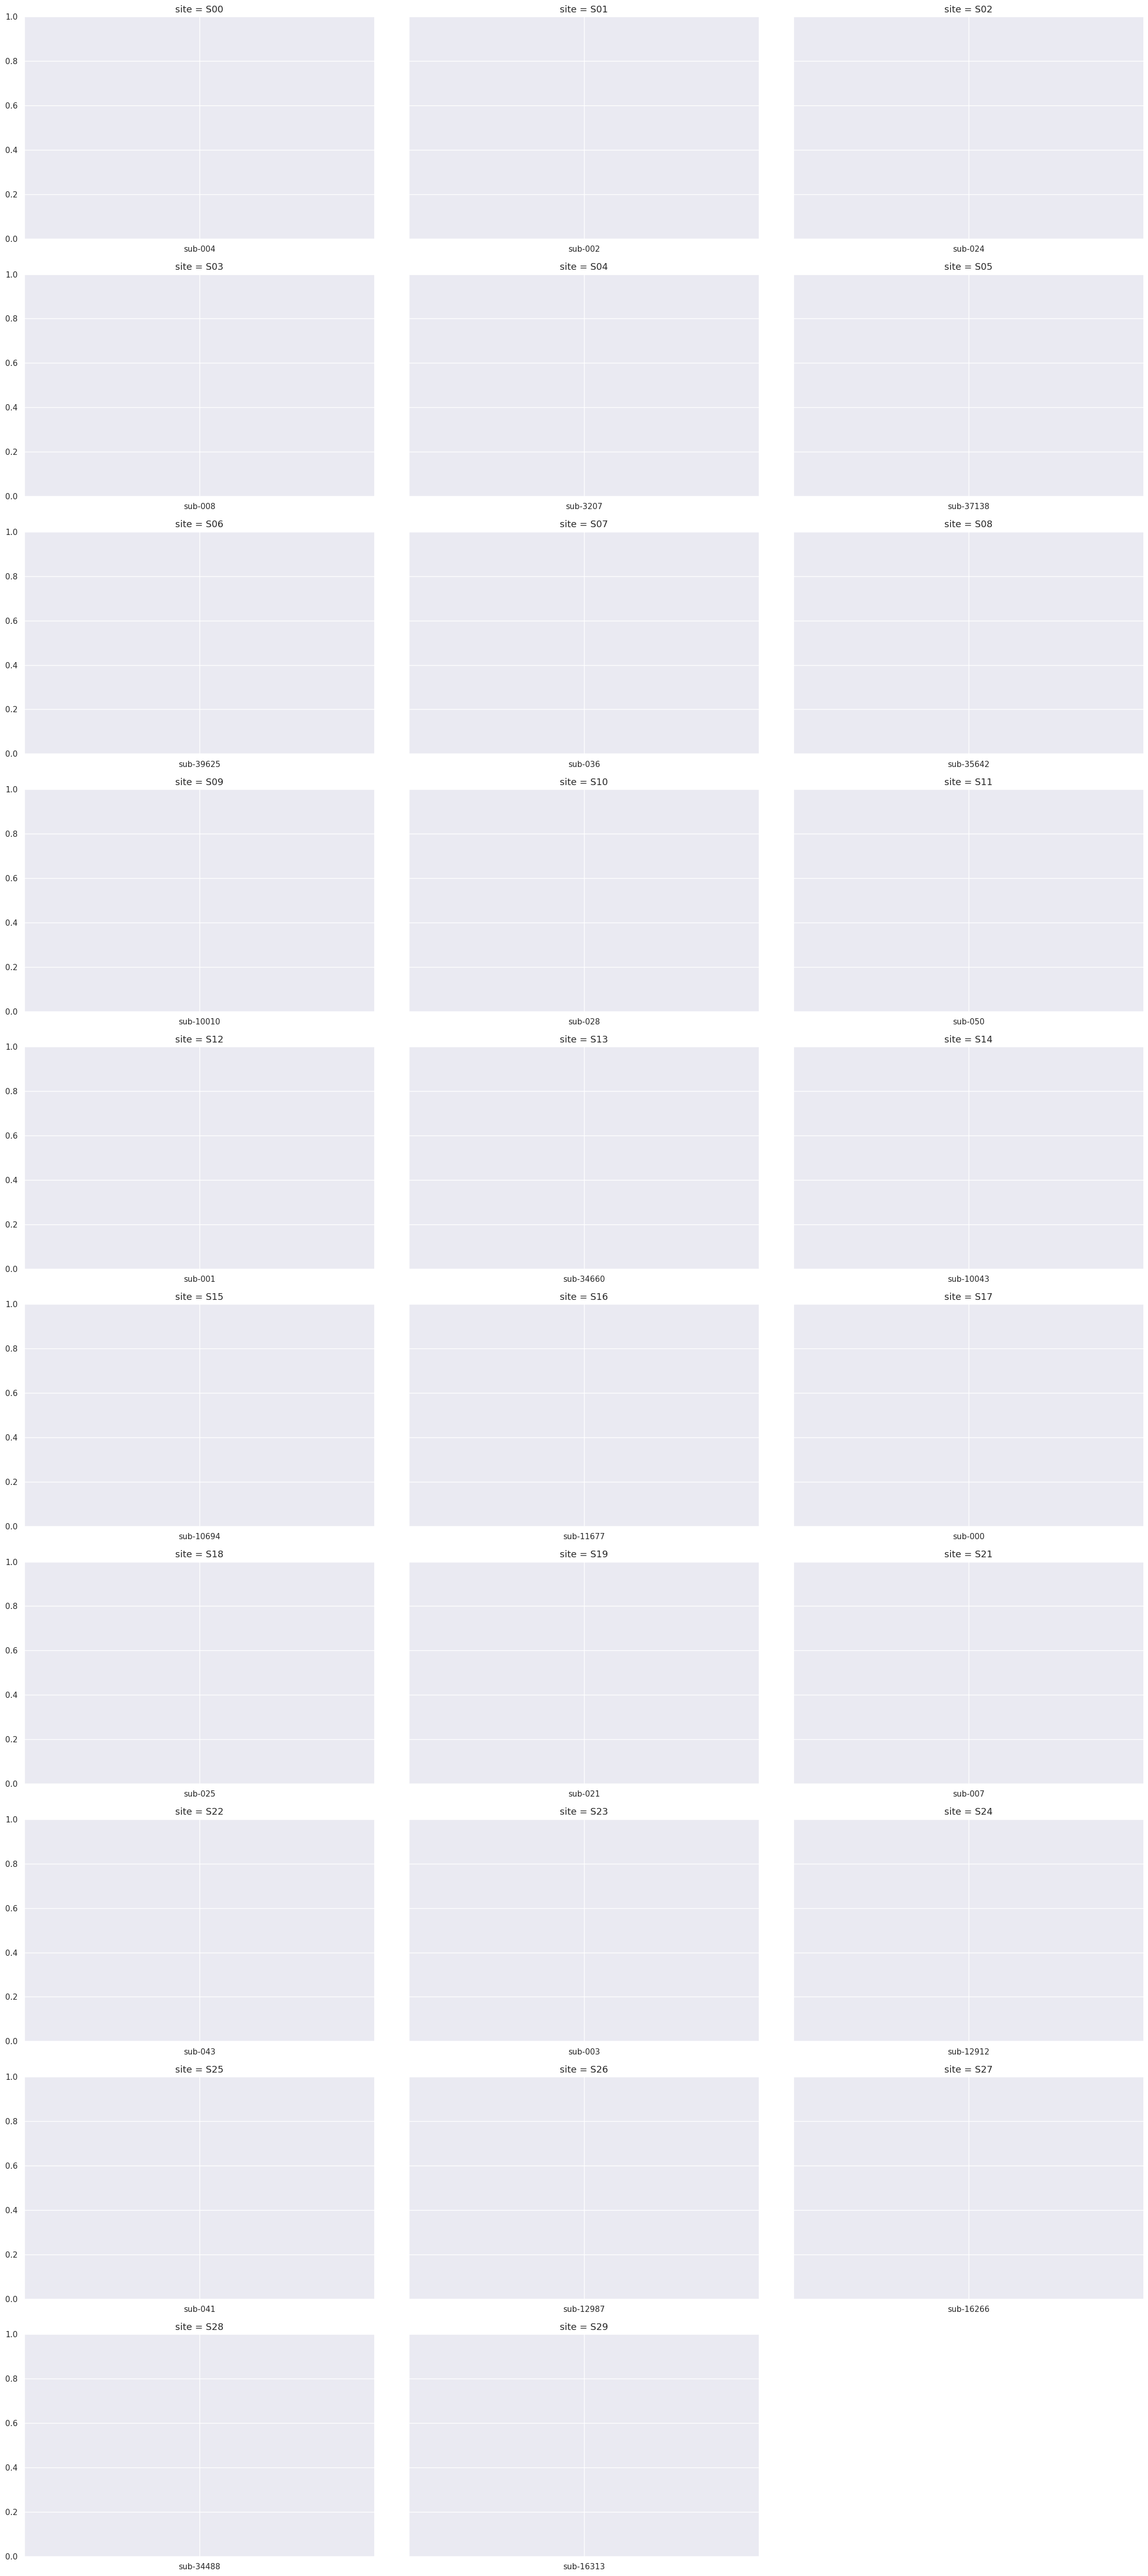

In [32]:
g = sns.catplot(
    data=data_long,
    x='sub_id',
    y='n_exams',
    kind='point',
    col="site", 
    col_wrap = 3,      
    hue="site",       
    sharex=False,# drop empty
    height=5,         
    aspect=1.5,
    size = 3)

g.set(xticks=[])
g.figure.suptitle("Distribution of longitudinal patients within each site", y=1.05)